In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc

# find starting cells

In [50]:
mul_adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_count_Jan13.h5ad")

In [51]:
mul_adata.var = mul_adata.var.set_index("Gene_Symbol")

In [52]:
# change datatype to normalize
mul_adata.X = mul_adata.X.astype('float64')

### basic filtering

In [53]:
sc.pp.filter_cells(mul_adata, min_genes=500)
sc.pp.filter_genes(mul_adata, min_cells=20)

In [54]:
mul_adata.var['mt'] = mul_adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(mul_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

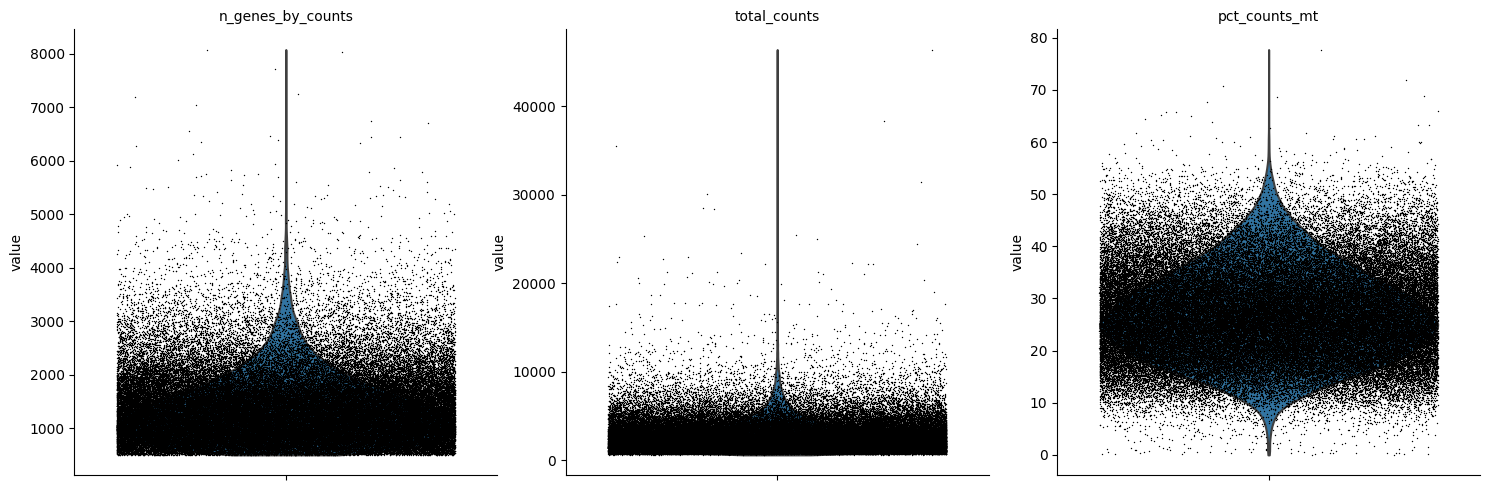

In [55]:
sc.pl.violin(mul_adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

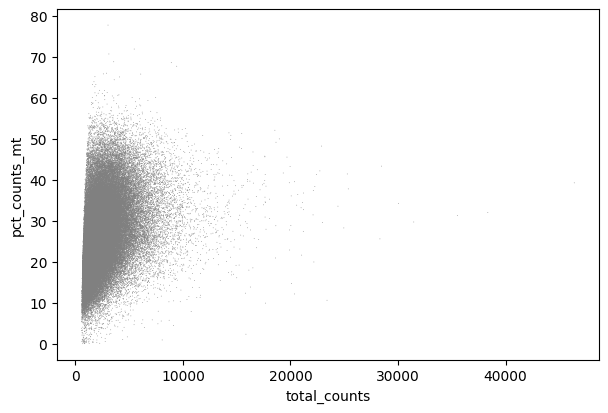

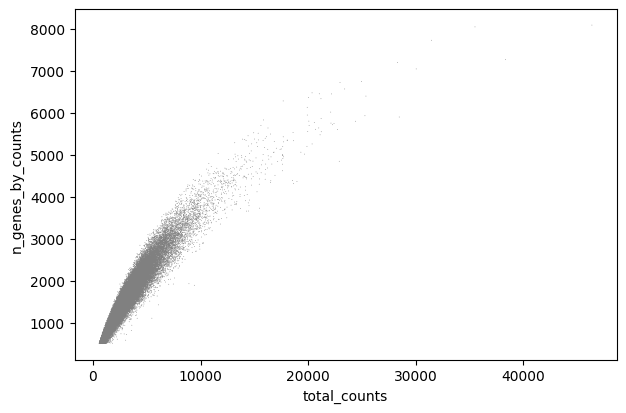

In [56]:
sc.pl.scatter(mul_adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(mul_adata, x='total_counts', y='n_genes_by_counts')

In [59]:
filter_adata = mul_adata[mul_adata.obs.n_genes_by_counts < 6000, :]
filter_adata = filter_adata[filter_adata.obs.pct_counts_mt < 50, :]

In [62]:
filter_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

## normalize and visualize

In [63]:
mul_adata = filter_adata

In [65]:
sc.pp.normalize_per_cell(mul_adata, counts_per_cell_after=10000, layers='all')
sc.pp.log1p(mul_adata)

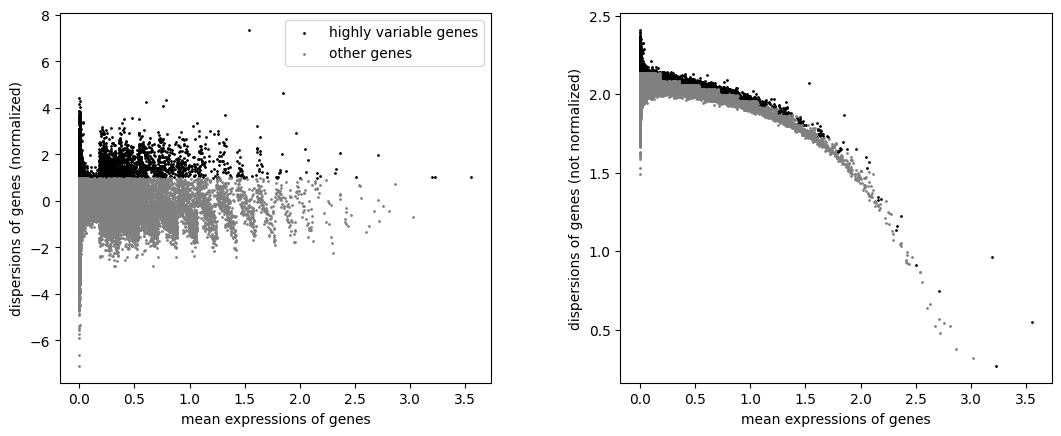

In [66]:
sc.pp.highly_variable_genes(mul_adata, n_top_genes=4000)
sc.pl.highly_variable_genes(mul_adata)

In [67]:
# pca and visualization

In [68]:
mul_adata.raw = mul_adata
mul_adata = mul_adata[:, mul_adata.var.highly_variable]
mul_adata

View of AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'ontarget_sgRNA'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [69]:
mul_adata = mul_adata[:, mul_adata.var.highly_variable]
mul_adata

View of AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    obsm: 'ontarget_sgRNA'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [71]:
sc.pp.regress_out(mul_adata, ['total_counts', 'pct_counts_mt'])

In [72]:
sc.pp.scale(mul_adata, max_value=10)

In [77]:
mul_adata

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'ontarget_sgRNA', 'X_pca'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'

In [73]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

## PCA

In [74]:
sc.tl.pca(mul_adata, svd_solver='arpack')

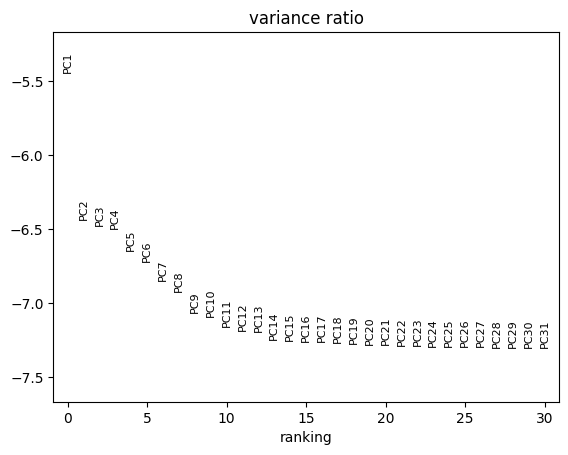

In [75]:
sc.pl.pca_variance_ratio(mul_adata, log=True)

In [79]:
sc.pp.neighbors(mul_adata, n_neighbors=550)

In [ ]:
sc.tl.umap(mul_adata)

In [85]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

# PAGA

In [2]:
mul_adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

In [3]:
mul_adata.obs.target.nunique()

489

In [4]:
sc.pp.neighbors(mul_adata, n_neighbors=50)
sc.tl.leiden(mul_adata, random_state = 0)

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


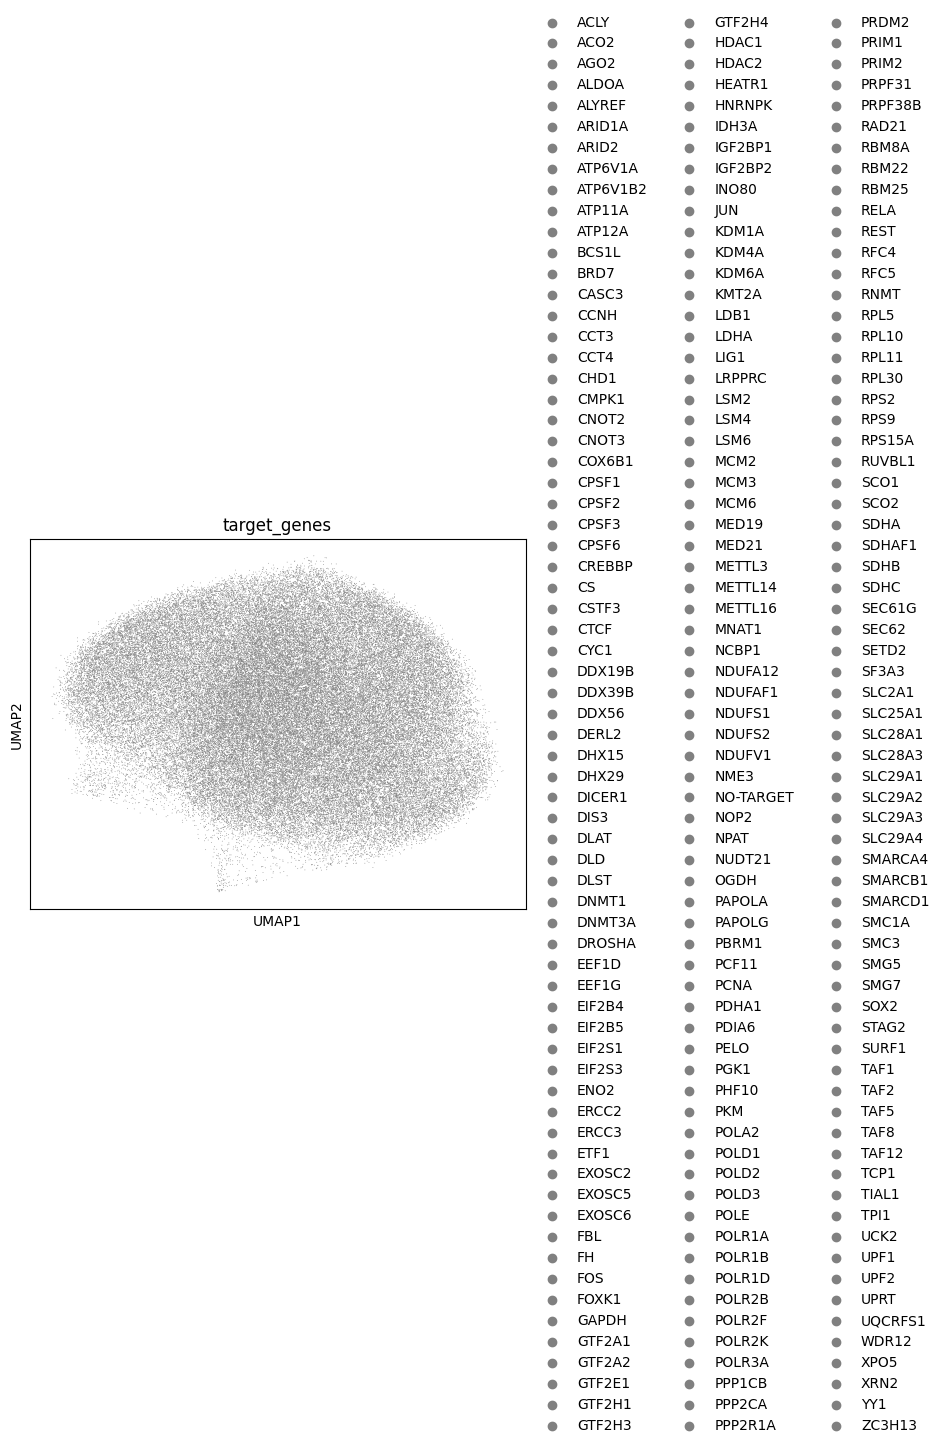

In [5]:
sc.pl.umap(mul_adata, color=['target_genes'])

In [7]:
sc.tl.leiden(mul_adata, resolution=0.8)

In [8]:
sc.tl.paga(mul_adata)
sc.pl.paga(mul_adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(mul_adata, init_pos='paga')

In [25]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/Preprocessed_Apr11.h5ad")

# **prepare the data for sampling**

In [ ]:
# TODO: prepare the `unique_token_dict`

In [41]:
with open('target_genes.txt', 'w') as f:
    for gene in mul_adata.obs.target_genes.cat.categories:
        f.write(gene+"\n")

In [40]:
with open('targets.txt', 'w') as f:
    for gene in mul_adata.obs.target.cat.categories:
        f.write(gene+"\n")

In [42]:
unique_token_dict = {g:i for i, g in enumerate(mul_adata.obs.target_genes.cat.categories)}

mul_adata.uns['unique_token_dict'] = unique_token_dict

In [54]:
# TODO: compute pseudo-time

In [45]:
# find the iroot for pseudotime analysis
mean_expression = mul_adata.X.mean(axis=0)

In [49]:
MSE = np.mean((mul_adata.X - mean_expression)**2, axis=1)

In [52]:
np.argmin(MSE), np.min(MSE)

(49323, 0.18360523322250327)

In [63]:
mul_adata.uns['iroot'] = 49323
cb_root = mul_adata.obs_names[mul_adata.uns['iroot']]

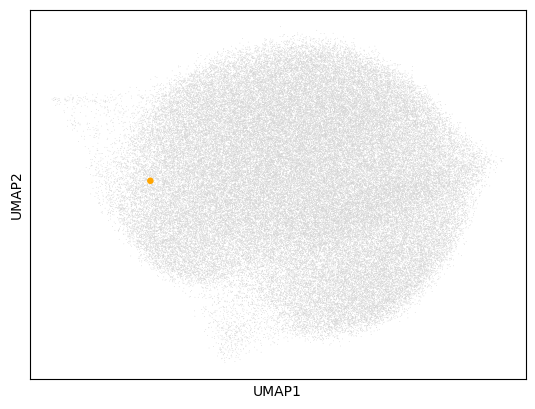

In [70]:
fig = sc.pl.umap(mul_adata, show=False, return_fig=True)
sc.pl.umap(mul_adata[cb_root], size=90, na_color='orange', ax=fig.gca())

In [72]:
sc.tl.diffmap(mul_adata, n_comps=10)

In [73]:
sc.tl.dpt(mul_adata)

In [74]:
mul_adata

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'dpt_pseudotime'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'leiden', 'target_genes_colors', 'paga', 'leiden_sizes', 'unique_token_dict', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'ontarget_sgRNA', 'X_diffmap'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'
    obsp: 'connectivities', 'distances'

## filter out the dettached cells

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


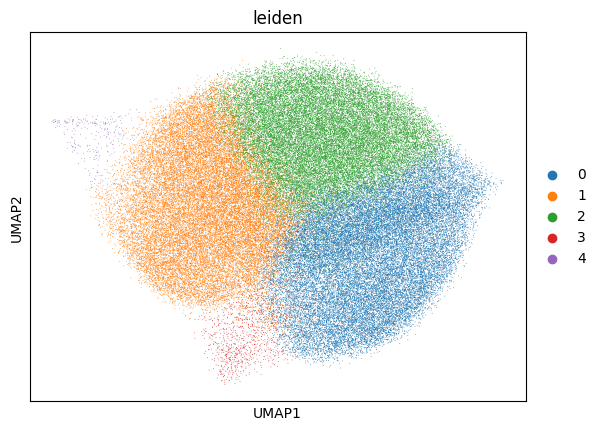

In [76]:
sc.pl.umap(mul_adata, color=['leiden'])

In [80]:
pure_cluster = ['0', '1', '2']
mul_adata_pure = mul_adata[mul_adata.obs.query("`leiden` in @pure_cluster").index].copy()

In [81]:
sc.tl.diffmap(mul_adata_pure, n_comps=10)
sc.tl.dpt(mul_adata_pure)

In [86]:
# discrete

def discrete_time(x):
    x = int(x*250)
    mid_err = np.random.randint(-2,2) # smooth the time
    tail_err = np.random.randint(0,10)
    return min(max(0,x+mid_err), 200-tail_err)

In [87]:
mul_adata_pure.obs['discrete_time'] = mul_adata_pure.obs['dpt_pseudotime'].apply(discrete_time)

In [89]:
mul_adata_pure.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

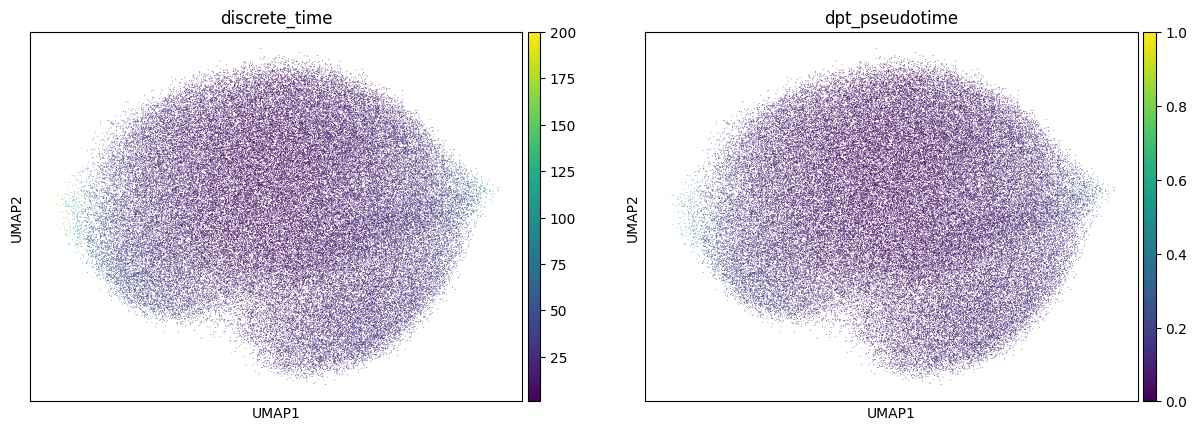

In [88]:
sc.pl.umap(mul_adata_pure, color=['discrete_time', 'dpt_pseudotime'])

In [90]:
mul_adata.obs['discrete_time'] = mul_adata.obs['dpt_pseudotime'].apply(discrete_time)

mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/Preprocessed_Apr11.h5ad")

In [91]:
from sklearn.model_selection import train_test_split